# SMILES Validator Analysis

In [1]:
import sys
sys.path.insert(0, '..')

from src import validate_smiles, parse_smiles
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter

# Validators
from rdkit import Chem
import partialsmiles as ps
import pysmiles
from molvs import validate_smiles as molvs_validate

# Keep per-molecule backend logging out of the comparison output.
import logging
logging.getLogger('pysmiles').setLevel(logging.CRITICAL)
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Parser debugging for SmilesParser written to parser.out


### The validators

- **YACC (original)** — the original hand-written validator, *reconstructed* for an old-vs-new comparison: regex aromatic/aliphatic hack + octet valency + heuristic Hückel on the legacy graph. (~57% pass on the 108k benchmark.)
- **py-yacc-smiles** — the current approach: our SLY/yacc **grammar owns syntax**, and **pysmiles owns chemistry** (valence + aromaticity), driven from the molecule graph *we* build, with pysmiles' own string parser bypassed (`docs/chemistry_backend_study.md`). Deliberately *permissive*: accepts hypervalent and radical species RDKit rejects; blocks only impossible valence, unkekulizable aromatics, and malformed syntax.
- **PySMILES** — pysmiles end-to-end (`read_smiles`: its own parser **and** chemistry). Contrasting `py-yacc-smiles` with `PySMILES` shows the value our grammar adds: on `data/invalid_smiles.parquet` our pipeline rejects 40/52 malformed strings vs pysmiles' 29/52.
- **RDKit**, **PartialSMILES**, **MolVS** — external references.

> ⚠️ **Two caveats — read before trusting the numbers below.**
>
> 1. **Stored outputs are stale** (single old `YACC` column). **Re-run the
>    notebook** to populate the new `YACC (original)` + `py-yacc-smiles` columns.
> 2. **The §1 "Ground Truth" hand set is biased and not trustworthy.** It is 126
>    narrow PAH/heteroarene variants, and its labels were *re-aligned to the
>    permissive policy*, so **`py-yacc-smiles` reads ~100% there by construction**
>    (the others, including `YACC (original)`, read lower because the labels now
>    encode py-yacc-smiles' decisions). §1 therefore cannot be used to judge
>    py-yacc-smiles. **The real comparison is §2 (the 108k benchmark) and
>    `data/invalid_smiles.parquet`.**


In [2]:
# Define all validators
import re
from src import parser, lexer, parser_manager
from chem.validator import ChemistryValidator

def validate_rdkit(mol: str) -> bool:
    try:
        return Chem.MolFromSmiles(mol) is not None
    except:
        return False

def validate_partialsmiles(mol: str) -> bool:
    try:
        ps.ParseSmiles(mol, partial=False)
        return True
    except:
        return False

def validate_pysmiles(mol: str) -> bool:
    # pysmiles end-to-end: its OWN parser AND chemistry (read_smiles).
    try:
        pysmiles.read_smiles(mol)
        return True
    except:
        return False

def validate_molvs(mol: str) -> bool:
    try:
        errors = molvs_validate(mol)
        return len(errors) == 0
    except:
        return False

def validate_py_yacc_smiles(mol: str) -> bool:
    # NEW hybrid approach: our SLY/yacc grammar owns SYNTAX; pysmiles owns
    # CHEMISTRY (valence + aromaticity), driven from the molecule graph we
    # build -- pysmiles' own string parser is bypassed. Contrast with the
    # 'PySMILES' row (pysmiles end-to-end). See docs/chemistry_backend_study.md.
    status, _ = validate_smiles(mol)
    return status

_original_chem = ChemistryValidator()

def validate_yacc_original(mol: str) -> bool:
    # The ORIGINAL hand-written validator, reconstructed for comparison: the
    # regex aromatic/aliphatic hack + octet valency + heuristic Hückel on the
    # legacy graph. (It runs on the current lexer, so it is ~3-5 pts more
    # permissive than the true original on bare two-letter atoms such as 'Cn';
    # the chemistry is identical to the original.)
    try:
        if re.search(r'C$', mol) and not re.search(r'C\d$', mol) and re.search(r'\d', mol):
            return False
        parser.parse(lexer.tokenize(mol))
        g = parser_manager.graph_builder.get_graph()  # legacy graph (with cycles)
        parser_manager.clear()
        ok, _ = _original_chem.validate_rings_and_valency(g)
        if not ok:
            return False
        ok, _ = _original_chem.validate_aromaticity(g)
        if not ok:
            return False
        return True
    except Exception:
        parser_manager.clear()
        return False

VALIDATORS = {
    'YACC (original)': validate_yacc_original,
    'py-yacc-smiles': validate_py_yacc_smiles,
    'RDKit': validate_rdkit,
    'PartialSMILES': validate_partialsmiles,
    'PySMILES': validate_pysmiles,
    'MolVS': validate_molvs,
}

In [3]:
hand_test = ["c1cc[c]2c(c1)oc3ccc23"] 

for mol in hand_test:
    print(mol+"\n\n") 
    for name, validator in VALIDATORS.items():
        print(name, validator(mol))



c1cc[c]2c(c1)oc3ccc23


YACC (original) False
py-yacc-smiles True
RDKit True
PartialSMILES True
PySMILES True
MolVS True


## 1. Ground Truth Validation (Test Dataset)

In [4]:
test_df = pd.read_parquet('../tests/data/test_molecules_from_values.parquet')
test_df = test_df.dropna(subset=['smiles'])
print(f"Test dataset: {len(test_df)} molecules ({test_df['is_valid'].sum()} valid, {(~test_df['is_valid']).sum()} invalid)")

Test dataset: 126 molecules (110 valid, 16 invalid)


In [5]:
# Run all validators
for name, validator in VALIDATORS.items():
    test_df[name] = test_df['smiles'].apply(validator)
test_df['ground_truth'] = test_df['is_valid']

### Metrics Comparison

In [6]:
def compute_metrics(y_true, y_pred, name):
    tp = ((y_true == True) & (y_pred == True)).sum()
    tn = ((y_true == False) & (y_pred == False)).sum()
    fp = ((y_true == False) & (y_pred == True)).sum()
    fn = ((y_true == True) & (y_pred == False)).sum()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {'Validator': name, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Accuracy': f'{accuracy:.2%}', 'Precision': f'{precision:.2%}', 
            'Recall': f'{recall:.2%}', 'F1': f'{f1:.2%}'}

metrics = [compute_metrics(test_df['ground_truth'], test_df[name], name) for name in VALIDATORS]
metrics_df = pd.DataFrame(metrics).sort_values('Accuracy', ascending=False)
display(metrics_df)

,Validator,TP,TN,FP,FN,Accuracy,Precision,Recall,F1
2,RDKit,109,16,0,1,99.21%,100.00%,99.09%,99.54%
5,MolVS,109,16,0,1,99.21%,100.00%,99.09%,99.54%
3,PartialSMILES,101,16,0,9,92.86%,100.00%,91.82%,95.73%
4,PySMILES,101,16,0,9,92.86%,100.00%,91.82%,95.73%
0,YACC (original),89,11,5,21,79.37%,94.68%,80.91%,87.25%
1,py-yacc-smiles,110,16,0,0,100.00%,100.00%,100.00%,100.00%


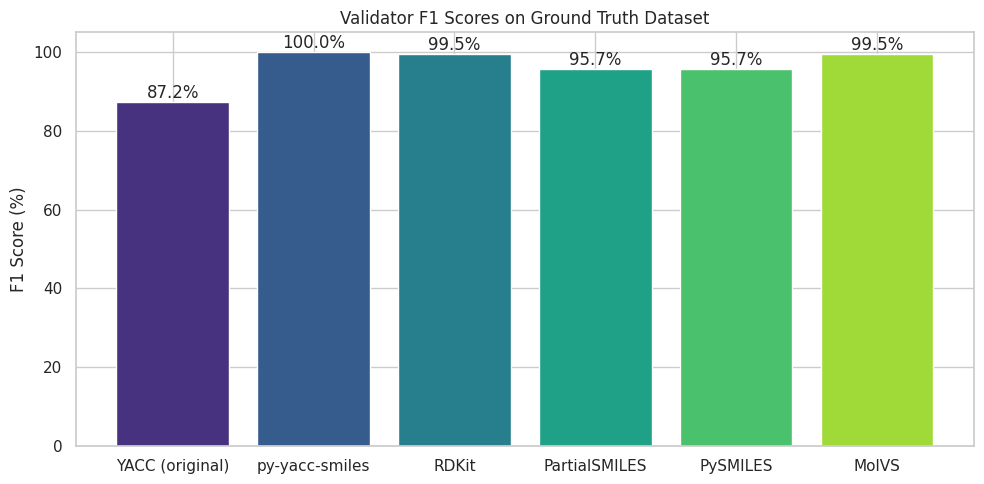

In [7]:
# Bar chart of F1 scores
fig, ax = plt.subplots(figsize=(10, 5))
f1_values = [float(m['F1'].strip('%')) for m in metrics]
colors = sns.color_palette('viridis', len(VALIDATORS))
bars = ax.bar([m['Validator'] for m in metrics], f1_values, color=colors)
ax.set_ylabel('F1 Score (%)')
ax.set_title('Validator F1 Scores on Ground Truth Dataset')
ax.set_ylim(0, 105)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('f1_scores.png', dpi=150)
plt.show()

### Confusion Matrices

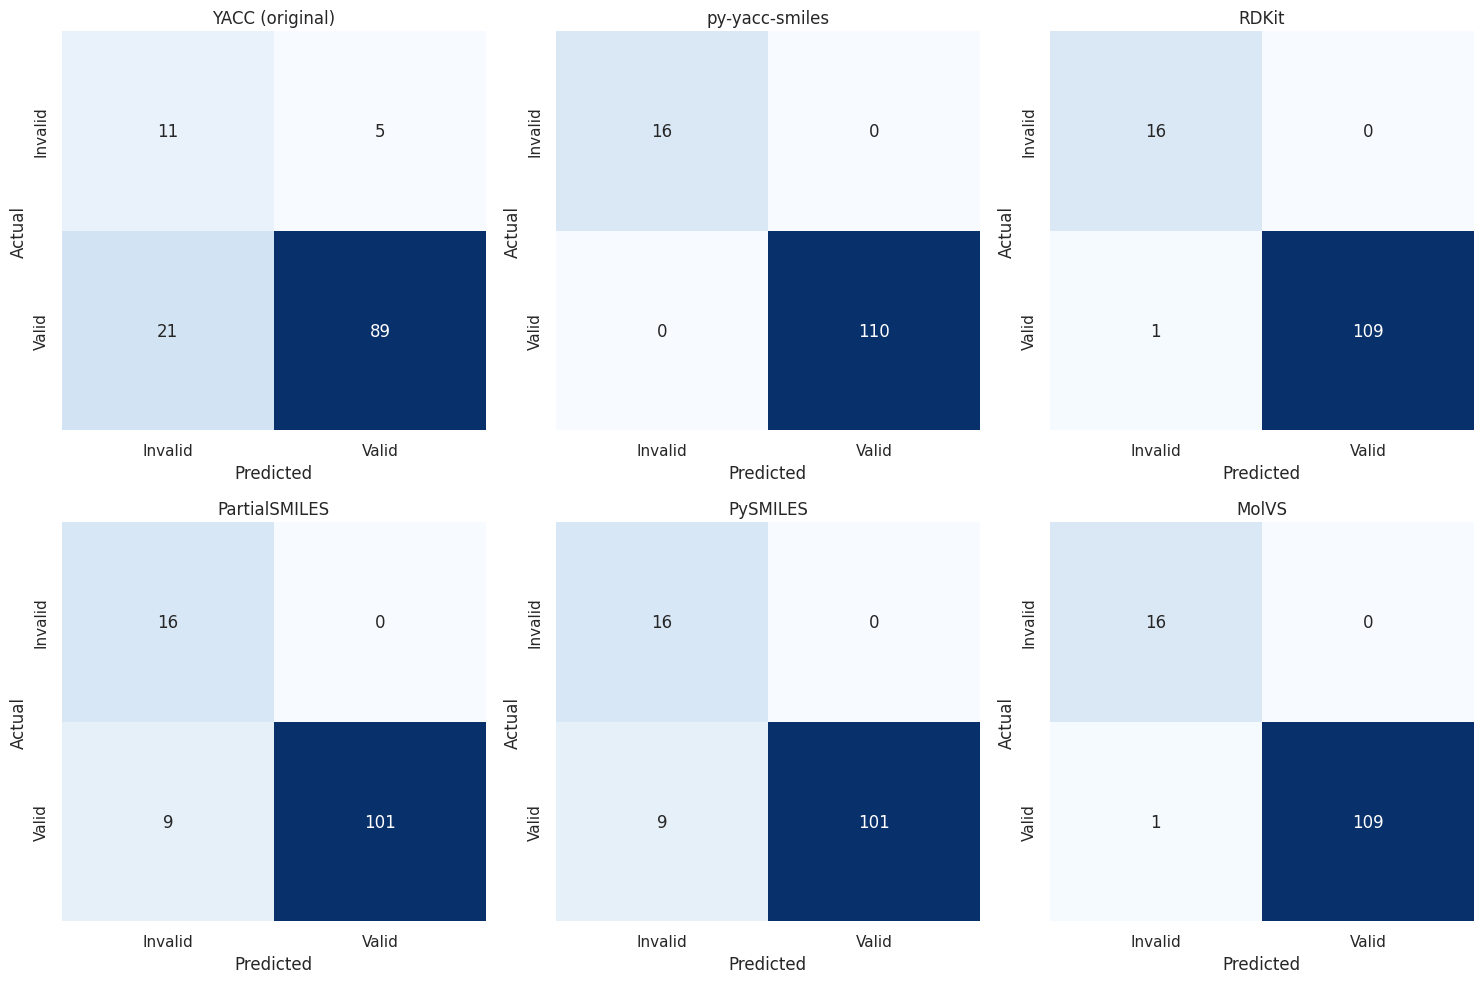

In [8]:
n = len(VALIDATORS)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, name in zip(axes, VALIDATORS.keys()):
    cm = pd.crosstab(test_df['ground_truth'], test_df[name], 
                     rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}')
    ax.set_xticklabels(['Invalid', 'Valid'])
    ax.set_yticklabels(['Invalid', 'Valid'])

# turn off any unused subplots
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

### False Positives Table

In [9]:
fp_counts = {name: ((test_df['ground_truth'] == False) & (test_df[name] == True)).sum() for name in VALIDATORS}
fp_df = pd.DataFrame(list(fp_counts.items()), columns=['Validator', 'False Positives']).sort_values('False Positives')
display(fp_df)

print("\nFalse Positives by Validator:")
for name in VALIDATORS:
    fps = test_df[(test_df['ground_truth'] == False) & (test_df[name] == True)]['smiles'].tolist()
    if fps:
        print(f"\n{name} ({len(fps)}):")
        for s in fps[:5]:
            print(f"  {s[:60]}")

,Validator,False Positives
1,py-yacc-smiles,0
2,RDKit,0
3,PartialSMILES,0
4,PySMILES,0
5,MolVS,0
0,YACC (original),5



False Positives by Validator:

YACC (original) (5):
  c1cc-[c]2c(=c1)c1=cc=cc3=cc=cc2=c13
  C1=CC2=CC=C3C=CC=C4C=CC(=C43)C=C2
  c1cc2cccc3c4cccc(c(c1)c2c3)c4cc5cccc5
  C1=CC2=C3C(=C1)C=CC=C3C3=C4C(=CC=CC4=CC=C23)C=C2
  c1cc2cccc3c4c[c]cc(c(c1)c2c3)c4cc5cccc5


### False Negatives Table

In [10]:
fn_counts = {name: ((test_df['ground_truth'] == True) & (test_df[name] == False)).sum() for name in VALIDATORS}
fn_df = pd.DataFrame(list(fn_counts.items()), columns=['Validator', 'False Negatives']).sort_values('False Negatives')
display(fn_df)

,Validator,False Negatives
1,py-yacc-smiles,0
2,RDKit,1
5,MolVS,1
3,PartialSMILES,9
4,PySMILES,9
0,YACC (original),21


## 2. Large Dataset Benchmark

In [11]:
# Per-dataset sample cap (keeps the 6-validator run tractable). Excludes the
# known-invalid set (data/invalid_smiles.parquet) -- these are real-molecule
# *positives* benchmarks. Strips surrounding whitespace so every validator gets
# clean input (some datasets, e.g. zinc250k, carry a trailing newline that a
# strict tokenizer would otherwise reject). Set SAMPLE_PER_DATASET=None for full.
SAMPLE_PER_DATASET = 3000

def load_benchmark_data(sample_per_dataset=SAMPLE_PER_DATASET):
    results = []
    for path in glob('../data/*.parquet'):
        dataset_name = path.split('/')[-1].replace('.parquet', '')
        if dataset_name == 'invalid_smiles':
            continue  # known-invalid set, not a positives benchmark
        df = pd.read_parquet(path)
        if 'smiles' not in df.columns:
            continue
        smis = df['smiles'].dropna().astype(str).str.strip()
        note = ''
        if sample_per_dataset and len(smis) > sample_per_dataset:
            smis = smis.sample(sample_per_dataset, random_state=42)
            note = f" (sampled from {len(df)})"
        for smiles in smis:
            results.append({'dataset': dataset_name, 'smiles': smiles})
        print(f"Loaded {dataset_name}: {len(smis)} molecules{note}")
    return pd.DataFrame(results)

bench_df = load_benchmark_data()
print(f"\nTotal: {len(bench_df)} molecules")

Loaded zinc250k: 3000 molecules (sampled from 249455)
Loaded mutagenicity: 3000 molecules (sampled from 4337)
Loaded muv: 3000 molecules (sampled from 93087)
Loaded clintox: 1484 molecules
Loaded tox21: 3000 molecules (sampled from 7831)
Loaded sider: 1427 molecules


Loaded qm9: 3000 molecules (sampled from 133885)

Total: 17911 molecules


In [12]:
# Run all validators
for name, validator in VALIDATORS.items():
    print(f"Running {name}...")
    bench_df[name] = bench_df['smiles'].apply(validator)

Running YACC (original)...


Running py-yacc-smiles...


Running RDKit...


Running PartialSMILES...


Running PySMILES...


Running MolVS...


### Validation Rates by Dataset

In [13]:
summary = bench_df.groupby('dataset').agg(
    {**{'smiles': 'count'}, **{name: 'mean' for name in VALIDATORS}}
).rename(columns={'smiles': 'count'})
for name in VALIDATORS:
    summary[name] = (summary[name] * 100).round(2)
display(summary)

,count,YACC (original),py-yacc-smiles,RDKit,PartialSMILES,PySMILES,MolVS
dataset,,,,,,,
clintox,1484,29.92,99.33,99.73,98.25,93.73,45.75
mutagenicity,3000,75.20,100.00,100.00,99.90,100.00,92.77
muv,3000,60.03,100.00,100.00,100.00,94.20,100.00
qm9,3000,85.47,100.00,100.00,99.80,100.00,99.77
sider,1427,58.58,100.00,100.00,96.57,97.41,86.12
tox21,3000,66.43,99.90,99.93,98.97,97.00,91.60
zinc250k,3000,43.53,100.00,100.00,100.00,94.90,73.10


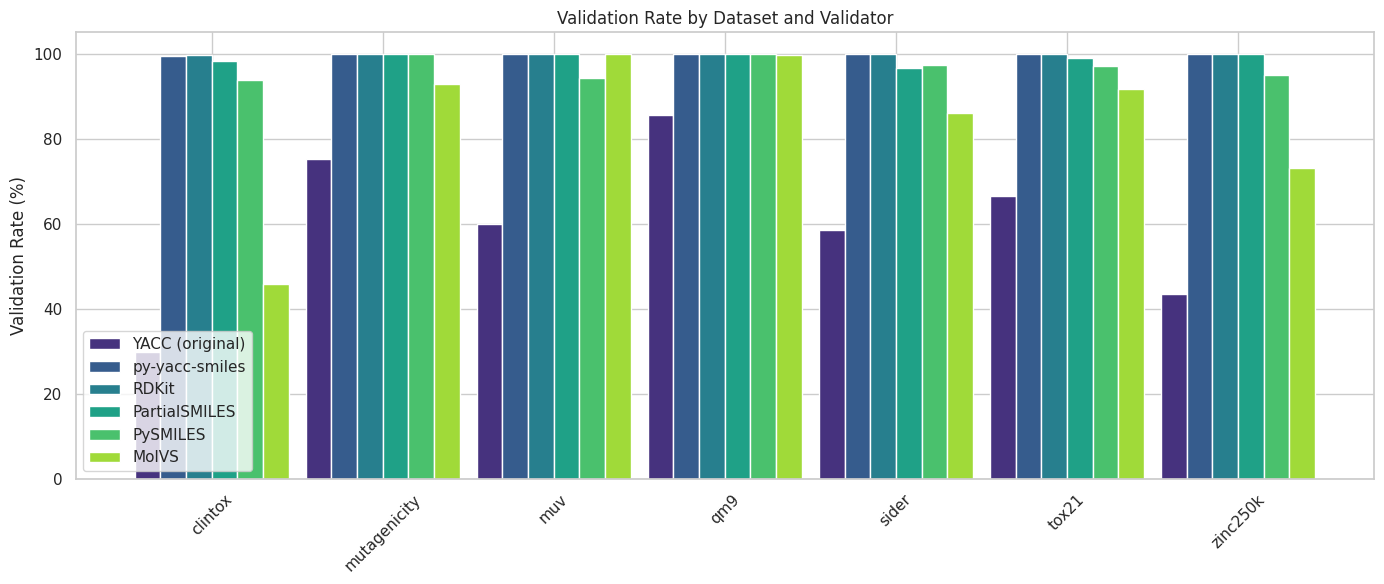

In [14]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary))
width = 0.15
colors = sns.color_palette('viridis', len(VALIDATORS))

for i, name in enumerate(VALIDATORS):
    offset = (i - len(VALIDATORS)/2 + 0.5) * width
    ax.bar(x + offset, summary[name], width, label=name, color=colors[i])

ax.set_ylabel('Validation Rate (%)')
ax.set_title('Validation Rate by Dataset and Validator')
ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=45)
ax.legend(loc='lower left')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('validation_rates.png', dpi=150)
plt.show()

### Overall Pass Rates

In [15]:
total = len(bench_df)
pass_rates = {name: bench_df[name].sum() / total * 100 for name in VALIDATORS}
pass_df = pd.DataFrame(list(pass_rates.items()), columns=['Validator', 'Pass Rate (%)']).sort_values('Pass Rate (%)', ascending=False)
pass_df['Pass Rate (%)'] = pass_df['Pass Rate (%)'].round(2)
display(pass_df)

,Validator,Pass Rate (%)
2,RDKit,99.97
1,py-yacc-smiles,99.93
3,PartialSMILES,99.36
4,PySMILES,96.95
5,MolVS,87.24
0,YACC (original),62.53


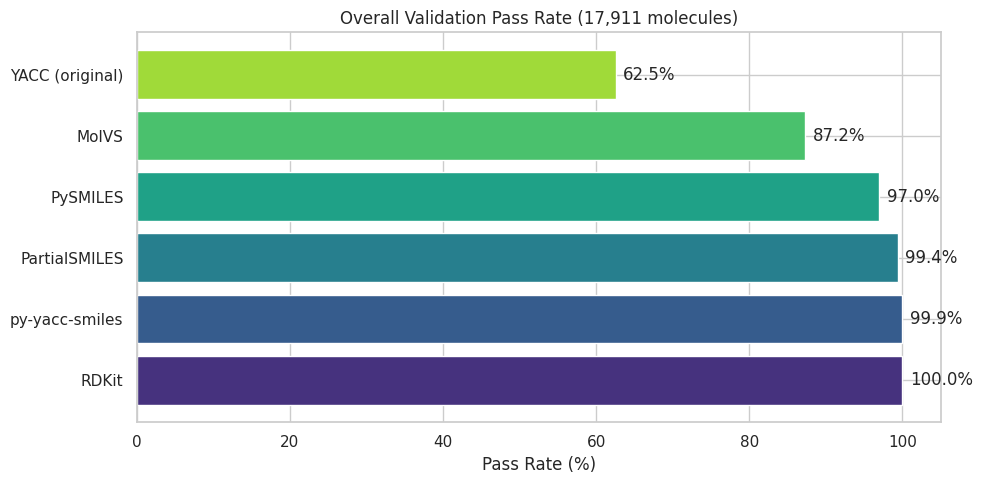

In [16]:
# Horizontal bar chart of pass rates
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('viridis', len(pass_df))
ax.barh(pass_df['Validator'], pass_df['Pass Rate (%)'], color=colors)
ax.set_xlabel('Pass Rate (%)')
ax.set_title(f'Overall Validation Pass Rate ({len(bench_df):,} molecules)')
ax.set_xlim(0, 105)
for i, val in enumerate(pass_df['Pass Rate (%)']):
    ax.text(val + 1, i, f'{val:.1f}%', va='center')
plt.tight_layout()
plt.savefig('pass_rates.png', dpi=150)
plt.show()

### Agreement Heatmap

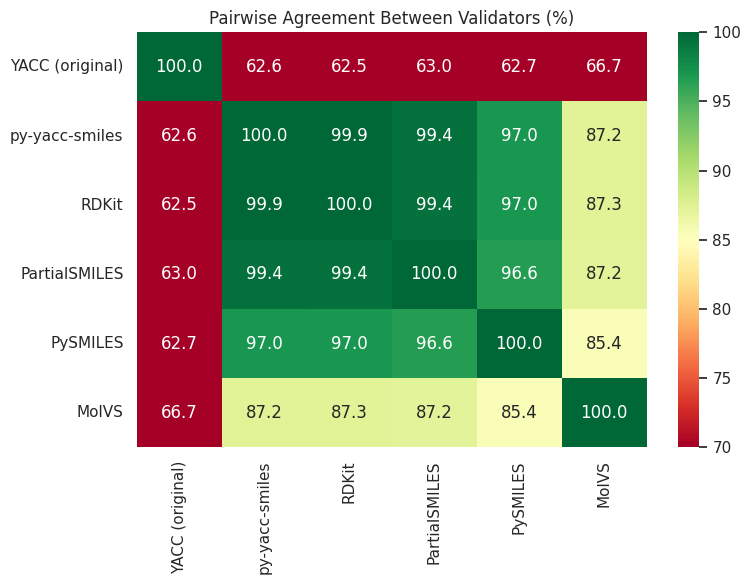

In [17]:
# Pairwise agreement between validators
agreement_matrix = pd.DataFrame(index=VALIDATORS.keys(), columns=VALIDATORS.keys(), dtype=float)
for v1 in VALIDATORS:
    for v2 in VALIDATORS:
        agreement = (bench_df[v1] == bench_df[v2]).mean() * 100
        agreement_matrix.loc[v1, v2] = agreement

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, vmin=70, vmax=100)
ax.set_title('Pairwise Agreement Between Validators (%)')
plt.tight_layout()
plt.savefig('agreement_heatmap.png', dpi=150)
plt.show()

### py-yacc-smiles Rejection Reasons

In [18]:
# Why does py-yacc-smiles reject a SMILES? (syntax vs chemistry)
rejects = bench_df[bench_df['py-yacc-smiles'] == False]['smiles'].head(500)

failure_reasons = []
for smiles in rejects:
    _, err = validate_smiles(smiles)
    if err:
        err_str = str(err)
        low = err_str.lower()
        if 'unclosed ring' in low:
            failure_reasons.append('Unclosed ring (syntax)')
        elif 'chemistry' in low or 'valence' in low or 'kekul' in low or 'aromatic' in low:
            failure_reasons.append('Chemistry (valence/aromaticity)')
        elif 'illegal character' in low or 'error on' in low or 'chain' in low or 'parser' in low or 'line' in low:
            failure_reasons.append('Syntax/parse error')
        else:
            failure_reasons.append('Other')

reason_df = pd.DataFrame(Counter(failure_reasons).items(), columns=['Reason', 'Count']).sort_values('Count', ascending=False)
reason_df['%'] = (reason_df['Count'] / reason_df['Count'].sum() * 100).round(1)
display(reason_df)

,Reason,Count,%
1,Chemistry (valence/aromaticity),8,61.5
0,Syntax/parse error,5,38.5


## 3. Summary

In [19]:
print("="*60)
print("SUMMARY")
print("="*60)
print(f"Ground truth test set: {len(test_df)} molecules")
print(f"Benchmark dataset: {len(bench_df):,} molecules")
print()
print("Ground Truth Performance (F1 Score):")
for m in sorted(metrics, key=lambda x: -float(x['F1'].strip('%'))):
    print(f"  {m['Validator']:15} {m['F1']}")
print()
print("Benchmark Pass Rates:")
for _, row in pass_df.iterrows():
    print(f"  {row['Validator']:15} {row['Pass Rate (%)']:.2f}%")

SUMMARY
Ground truth test set: 126 molecules
Benchmark dataset: 17,911 molecules

Ground Truth Performance (F1 Score):
  py-yacc-smiles  100.00%
  RDKit           99.54%
  MolVS           99.54%
  PartialSMILES   95.73%
  PySMILES        95.73%
  YACC (original) 87.25%

Benchmark Pass Rates:
  RDKit           99.97%
  py-yacc-smiles  99.93%
  PartialSMILES   99.36%
  PySMILES        96.95%
  MolVS           87.24%
  YACC (original) 62.53%
